<a href="https://colab.research.google.com/github/Madankk-06/MadanKK-gen-ai-foundations/blob/main/1_Vectorized_Scaled_Dot_Product_Attention_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [11]:
# ==========================
# Generate Dummy Input
# Shape:
# Batch = 2
# Heads = 4
# Sequence Length = 5
# Embedding Dimension per Head = 8
# ==========================

batch_size = 2
num_heads = 4
seq_len = 5
d_k = 8

Q = np.random.randn(batch_size, num_heads, seq_len, d_k)
K = np.random.randn(batch_size, num_heads, seq_len, d_k)
V = np.random.randn(batch_size, num_heads, seq_len, d_k)

print("Q Shape:", Q.shape)
print("K Shape:", K.shape)
print("V Shape:", V.shape)

Q Shape: (2, 4, 5, 8)
K Shape: (2, 4, 5, 8)
V Shape: (2, 4, 5, 8)


In [12]:
def softmax(x, axis=-1):
    """
    Numerically stable softmax
    """

    x = x - np.max(x, axis=axis, keepdims=True)

    exp_x = np.exp(x)

    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

In [13]:
def causal_mask(seq_len):
    """
    Creates lower triangular mask
    """

    mask = np.triu(np.ones((seq_len, seq_len)), k=1)

    return mask.astype(bool)

mask = causal_mask(seq_len)

print(mask)

[[False  True  True  True  True]
 [False False  True  True  True]
 [False False False  True  True]
 [False False False False  True]
 [False False False False False]]


In [14]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Vectorized Scaled Dot-Product Attention

    Parameters
    ----------
    Q : Query
    K : Key
    V : Value

    Shapes
    ------
    Q : (B,H,L,D)
    K : (B,H,L,D)
    V : (B,H,L,D)

    Returns
    -------
    output
    attention_weights
    """

    d_k = Q.shape[-1]

    # Step 1
    # Q × Kᵀ

    scores = np.matmul(Q, K.transpose(0,1,3,2))

    # Step 2
    # Scale


    scores = scores / np.sqrt(d_k)


    # Step 3
    # Apply Mask


    if mask is not None:
        scores = np.where(mask, -1e9, scores)


    # Step 4
    # Softmax


    attention_weights = softmax(scores)


    # Step 5
    # Multiply with V


    output = np.matmul(attention_weights, V)

    return output, attention_weights

In [15]:
output, attention = scaled_dot_product_attention(
    Q,
    K,
    V,
    mask
)

print("Attention Shape :", attention.shape)
print("Output Shape    :", output.shape)

Attention Shape : (2, 4, 5, 5)
Output Shape    : (2, 4, 5, 8)


In [16]:
print("Row Sum Check")

print(np.sum(attention[0,0], axis=-1))

Row Sum Check
[1. 1. 1. 1. 1.]


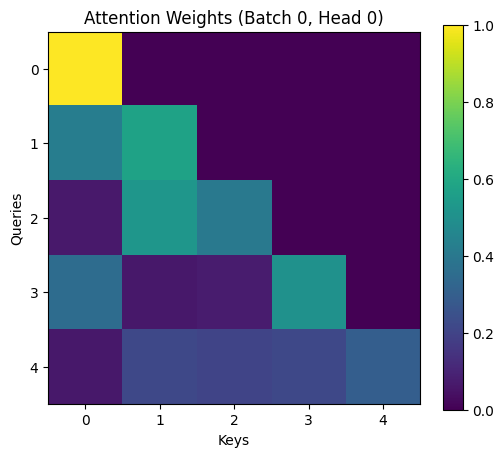

In [17]:
plt.figure(figsize=(6,5))

plt.imshow(attention[0,0], cmap='viridis')

plt.colorbar()

plt.title("Attention Weights (Batch 0, Head 0)")

plt.xlabel("Keys")

plt.ylabel("Queries")

plt.show()

In [18]:
print("Attention Matrix")

print(attention[0,0])

print("\nOutput")

print(output[0,0])

Attention Matrix
[[1.         0.         0.         0.         0.        ]
 [0.42394876 0.57605124 0.         0.         0.        ]
 [0.0688286  0.52679372 0.40437768 0.         0.        ]
 [0.35521404 0.06579462 0.07481087 0.50418047 0.        ]
 [0.06268651 0.21625096 0.206789   0.21646233 0.2978112 ]]

Output
[[-0.3357847   1.66902153 -0.25959135 -1.50314295 -0.24574306 -0.27272357
  -2.69688664 -0.05429487]
 [-0.27538563  1.10863015  0.95504001  0.01170358 -0.25907613 -0.75303644
   0.33904534  0.01109461]
 [-0.13913375  0.4718779   1.03625221  0.43163203 -0.39053914 -0.82281963
   1.15676217 -0.19228999]
 [-0.49283055  0.69052174 -0.08429477  0.2876686  -1.48446617  0.33972675
  -0.16285726 -1.10140699]
 [-0.32446902  0.16261051 -0.04983829  0.21345716 -1.09675624  0.38864808
   0.92904613 -0.17309932]]


In [19]:
assert Q.shape == (2,4,5,8)
assert K.shape == (2,4,5,8)
assert V.shape == (2,4,5,8)

assert attention.shape == (2,4,5,5)
assert output.shape == (2,4,5,8)

print("All shape tests passed.")

All shape tests passed.


In [20]:
print("Time Complexity : O(B × H × L² × D)")
print("Space Complexity: O(B × H × L²)")

Time Complexity : O(B × H × L² × D)
Space Complexity: O(B × H × L²)


In [21]:
print("""
Task 1 Completed Successfully

Implemented:
✓ Pure NumPy
✓ Batch Processing
✓ Multi-Head Attention
✓ Vectorized Matrix Multiplication
✓ Stable Softmax
✓ Scaled Dot Product
✓ Decoder Causal Mask
✓ Output Verification
✓ Attention Visualization
""")


Task 1 Completed Successfully

Implemented:
✓ Pure NumPy
✓ Batch Processing
✓ Multi-Head Attention
✓ Vectorized Matrix Multiplication
✓ Stable Softmax
✓ Scaled Dot Product
✓ Decoder Causal Mask
✓ Output Verification
✓ Attention Visualization

